# Figure6_2

In [1]:
from pathlib import Path

FIGURE_OUTPUT_DIR = Path("results/Figure6")
FIGURE_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import t, pearsonr

from functions.utils import index_in
from functions.sensitivity import load_human_fits, load_monkey_fits
from functions.plotting import set_paper_theme, plot_linear_fit_ci

set_paper_theme(tick_width=0.3, unicode_minus=False)


In [3]:
task_label = [
    "Animate vs. Inanimate",
    "Natural vs. Artificial",
    "Maml. vs. Nonmaml.",
    "Monkey vs. Mammal",
    "Human vs. Monkey",
    "Tools vs. Electronics",
]
task_list = [
    "animate_vs_inanimate",
    "natural_vs_artificial", 
    "mammal_vs_reptile", 
    "monkey_vs_mammal",
    "human_vs_monkey",
    "electronics_vs_tools"    
    ]

subj_list = [
    ["012","014","041","042","043","044","072"],
    ["012","013","017","041","042","043","072"],
    ["012","013","017","041","042","043","072"],
    ["012","013","017","041","042","043","072"],
    ["012","013","017","041","042","043","072"],
    ["012","013","017","041","042","043","072"],
]

## Panel E — Natural vs. Artificial

In [4]:
task = "natural_vs_artificial"

uimg_monkey,k_monkey = load_monkey_fits(task)
uimg_human,k_human = load_human_fits(task,subj_list[1])

kavg_monkey = np.mean(k_monkey,axis=0)
kavg_human = np.mean(k_human,axis=0)

In [5]:
df = pd.DataFrame({"img":uimg_monkey[0],"kavg_human":kavg_human,"kavg_monkey":kavg_monkey})
exp_img = ["010706700086.png","010801001611.png","040511000414.png","010511000374.png"]
idx = index_in(exp_img,df.img)
df.iloc[idx]

,img,kavg_human,kavg_monkey
50,010706700086.png,0.114033,0.055991
64,010801001611.png,0.203705,0.143442
78,040511000414.png,0.188643,0.024826
14,010511000374.png,0.149461,0.120163


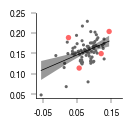

In [6]:

fig,ax = plt.subplots()
fig.set(figwidth=90/75,figheight=90/75)
ax.set_box_aspect(1)

non_example = np.ones(len(kavg_human),dtype=bool)
non_example[idx] = False
ax.scatter(kavg_monkey[non_example],
           kavg_human[non_example],
           s=5,color="#666666",edgecolors="None")
ax.scatter(kavg_monkey[idx],kavg_human[idx],s=15,color=("red",0.6),edgecolors="None")
ax.set_xticks([-0.05,0.05,0.15],["-0.05","0.05","0.15"])

ax.set_xlim(-0.07,0.18)
ax.set_ylim(0.04,0.25)

plot_linear_fit_ci(ax,kavg_monkey,kavg_human)

plt.savefig(FIGURE_OUTPUT_DIR / "sensitivity_example_natural_vs_artificial.pdf",transparent=True)
plt.show()


## Panel E — Monkey vs. Mammal

In [7]:
task = "monkey_vs_mammal"

uimg_monkey,k_monkey = load_monkey_fits(task)
uimg_human,k_human = load_human_fits(task,subj_list[1])

kavg_monkey = np.mean(k_monkey,axis=0)
kavg_human = np.mean(k_human,axis=0)


df = pd.DataFrame({"img":uimg_monkey[0],"kavg_human":kavg_human,"kavg_monkey":kavg_monkey})
exp_img = ["010304702260.png","020205401114.png","040205401159.png"]
idx = np.array(index_in(exp_img,df.img))

0.35345710328626


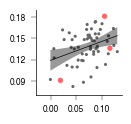

In [8]:

fig,ax = plt.subplots()
fig.set(figwidth=90/75,figheight=90/75)
ax.set_box_aspect(1)

non_example = np.ones(len(kavg_human),dtype=bool)
non_example[idx] = False
ax.scatter(kavg_monkey[non_example],
           kavg_human[non_example],
           s=5,color="#666666",edgecolors="None")
print(np.corrcoef(kavg_monkey,kavg_human)[0,1])
ax.scatter(kavg_monkey[idx],kavg_human[idx],s=15,color=("red",0.6),edgecolors="None")
ax.set_xticks([0,0.05,0.1])
ax.set_yticks([0.09,0.12,0.15,0.18])
ax.set_xlim(-0.03,0.14)
ax.set_ylim(0.07,0.19)

plot_linear_fit_ci(ax,kavg_monkey,kavg_human)

plt.savefig(FIGURE_OUTPUT_DIR / "sensitivity_example_monkey_vs_mammal.pdf",transparent=True)
plt.show()


## Panel F - Human-monkey correlation summary

In [9]:

# Per-task human-monkey correlation (cross-subject mean k each) + analytic SE.
corr_mean = np.zeros(len(task_list))
corr_pvalue = np.zeros(len(task_list))
corr_se = np.zeros(len(task_list))
for (n,task) in enumerate(task_list):
    uimg_monkey,k_monkey = load_monkey_fits(task)
    uimg_human,k_human = load_human_fits(task,subj_list[n])

    kavg_monkey = np.mean(k_monkey,axis=0)
    kavg_human = np.mean(k_human,axis=0)
    res,p_value = pearsonr(kavg_monkey,kavg_human)
    print(f"correlation:{res:.4};p_value:{p_value:.4}")
    corr_mean[n] = np.corrcoef(kavg_monkey,kavg_human)[0,1]
    corr_pvalue[n] = p_value
    corr_se[n] = np.sqrt( (1-corr_mean[n]**2)/(len(kavg_human)-2) )


correlation:0.37;p_value:0.0002073
correlation:0.4281;p_value:7.444e-05
correlation:0.3049;p_value:0.005958
correlation:0.3535;p_value:0.0056
correlation:0.4102;p_value:0.001135
correlation:0.3802;p_value:0.0005035


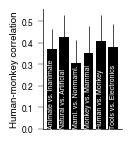

Saved -> results/Figure6/sensitivity_correlation_by_task.pdf


In [10]:
# Panel F: per-task human-monkey correlation bars; task labels in white
# inside the black bars (as in the compiled manuscript panel).
# layout='none' + measured left margin: constrained_layout clips the tall
# rotated ylabel at this figure size, so the axes is nudged right until the
# ylabel's actual rendered extent fits inside the canvas.
fig,ax = plt.subplots(layout="none")
fig.set(figheight=100/75,figwidth=90/75)
fig.subplots_adjust(left=0.22, right=0.98, top=0.97, bottom=0.10)

ax.bar(range(len(task_list)),corr_mean,color="black",yerr=corr_se,error_kw={"linewidth":0.5})
for i in range(6): ax.text(i,0.01,task_label[i],color="white",horizontalalignment="center",fontsize=5,rotation=90)
ax.set_xticks([])
ax.set_ylabel("Human-monkey correlation", labelpad=2)

# Push the axes right just enough that the ylabel fits (2pt clearance).
fig.canvas.draw()
bb = ax.yaxis.label.get_window_extent(fig.canvas.get_renderer())
overflow_px = -bb.x0
if overflow_px > 0:
    delta = overflow_px / (fig.get_figwidth() * fig.dpi) + 0.003
    fig.subplots_adjust(left=fig.subplotpars.left + delta)

plt.savefig(FIGURE_OUTPUT_DIR / f"sensitivity_correlation_by_task.pdf")
plt.show()
print(f"Saved -> results/Figure6/sensitivity_correlation_by_task.pdf")